In [1]:
import os
import glob
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

In [2]:
# =====================================================================
# 0. CONFIGURAZIONE E VERIFICA GPU
# =====================================================================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Consente a TF di allocare memoria sulla GPU man mano che serve, 
        # invece di allocare il 100% della VRAM istantaneamente (evita crash su cluster)
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"=== GPU Rilevata con successo! Disponibili: {len(gpus)} GPU ===")
        print(f"Dettagli: {gpus}")
    except RuntimeError as e:
        print(f"Errore nella configurazione della GPU: {e}")
else:
    print("=== [ATTENZIONE] Nessuna GPU rilevata. Il codice girerà in CPU (Molto lento) ===")

=== [ATTENZIONE] Nessuna GPU rilevata. Il codice girerà in CPU (Molto lento) ===


In [2]:
# =====================================================================
# 1. HELPER FUNCTIONS
# =====================================================================

def load_all_images(folder, img_size=(128,128)):
    """Load grayscale images from folder, normalize globally to [0,1]."""
    exts = ['*.png', '*.PNG', '*.jpg', '*.jpeg', '*.bmp', '*.gif']
    paths = []
    for e in exts:
        paths.extend(glob.glob(os.path.join(folder, e)))
    paths = sorted(paths)
    imgs = []
    for p in paths:
        try:
            im = Image.open(p).convert("L")  # grayscale
            im = im.resize(img_size, Image.BILINEAR)
            arr = np.array(im, dtype=np.float32) / 255.0  # scale to [0,1]
            imgs.append(arr[..., None])  # add channel dim
        except Exception as e:
            print(f"[load_all_images] skipping {p}: {e}")
            
    if len(imgs) == 0:
        raise RuntimeError(f"No images loaded from {folder}")
    return np.stack(imgs, axis=0) 

def augment_tf(img):
    """Simple augmentation: random flips + 90° rotations."""
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    img = tf.image.rot90(img, k)
    return img

In [ ]:
# =====================================================================
# 2. DATA ASSEMBLY PIPELINE (APPROCCIO PURE DATA-DRIVEN)
# =====================================================================
import os
import glob
import numpy as np
import tensorflow as tf
from PIL import Image

print("=== Loading Datasets ===")

# A. Load Real Data (I NOSTRI UNICI DATI DI ADDESTRAMENTO PER L'ENCODER)
print("Loading real background (STD)...", end="", flush=True)
std_images_real = load_all_images("Dataset_Preparation/STD_images_train")
print(f" Done! ({len(std_images_real)} images)")

print("Loading real mixture (AmBe)...", end="", flush=True)
ambe_images_real = load_all_images("Dataset_Preparation/AmBe_images_train")
print(f" Done! ({len(ambe_images_real)} images)")

# Uniamo STD e AmBe: questo è l'unico calderone che vedrà SimCLR
X_real = np.concatenate([std_images_real, ambe_images_real], axis=0)
print(f"\nFinal Dataset Size for Pre-training (Solo Dati Reali!): {X_real.shape}")


# B. Load Simulated Data (LI TENIAMO SOLO IN RAM PER I TEST FUTURI)
energies = [1, 3, 5, 10, 15, 20, 25, 35, 45, 50]
sim_base = "MC_Reconstructed_Dataset/output_images"

ER_simulated = []
NR_simulated = []

print("\nCaricamento simulazioni (Saranno escluse dal pre-training, tenute solo per test)...")
for energy in energies:
    er_folder = os.path.join(sim_base, f"{energy}_keV", f"image_CYGNO_60_40_ER_{energy}_keV")
    if os.path.exists(er_folder):
        imgs = load_all_images(er_folder)
        ER_simulated.append(imgs)
        
    nr_folder = os.path.join(sim_base, f"{energy}_keV", f"image_CYGNO_60_40_He_{energy}_keVee")
    if os.path.exists(nr_folder):
        imgs = load_all_images(nr_folder)
        NR_simulated.append(imgs)

# Variabili tenute in vita per non rompere il resto del codice
X_sim_er = np.concatenate(ER_simulated, axis=0) if len(ER_simulated) > 0 else np.array([])
X_sim_nr = np.concatenate(NR_simulated, axis=0) if len(NR_simulated) > 0 else np.array([])


# C. Pipeline tf.data (ESTREMAMENTE SEMPLIFICATA)
BATCH_SIZE = 128 

# Nessun mixing, nessun background, nessun flag. 
# Prendiamo l'immagine reale e applichiamo solo le rotazioni spaziali.
def prepare_contrastive_pair(img):
    """Crea due viste aumentate della stessa immagine REALE."""
    view_i = augment_tf(img)
    view_j = augment_tf(img)
    return view_i, view_j

# Costruiamo il dataset iterabile passando SOLO X_real
dataset = tf.data.Dataset.from_tensor_slices(X_real)
dataset = dataset.shuffle(buffer_size=1024)
dataset = dataset.map(prepare_contrastive_pair, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.batch(BATCH_SIZE, drop_remainder=True)
dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

print("\nPipeline tf.data per Fase 1 pronta (Zero Simulazioni).")

=== Loading Datasets ===
Loading real background (STD)... Done! (14750 images)
Loading real mixture (AmBe)... Done! (14724 images)
Loading Sim ER (1 keV)... Done! (1402 images)
Loading Sim NR (1 keV)... Done! (1714 images)
Loading Sim ER (3 keV)... Done! (1742 images)
Loading Sim NR (3 keV)... Done! (1736 images)
Loading Sim ER (5 keV)... Done! (1716 images)
Loading Sim NR (5 keV)... Done! (1706 images)
Loading Sim ER (10 keV)... Done! (1726 images)
Loading Sim NR (10 keV)... Done! (1722 images)
Loading Sim ER (15 keV)... Done! (1754 images)
Loading Sim NR (15 keV)... Done! (1398 images)
Loading Sim ER (20 keV)... Done! (1692 images)
Loading Sim NR (20 keV)... Done! (1662 images)
Loading Sim ER (25 keV)... Done! (1772 images)
Loading Sim NR (25 keV)... Done! (1708 images)
Loading Sim ER (35 keV)... Done! (1706 images)
Loading Sim NR (35 keV)... Done! (1730 images)
Loading Sim ER (45 keV)... Done! (1724 images)
Loading Sim NR (45 keV)... Done! (1754 images)
Loading Sim ER (50 keV)... Do

In [4]:
# =====================================================================
# 3. SIMCLR ARCHITECTURE & LOSS
# =====================================================================

def build_contrastive_network(input_shape=(128, 128, 1), embedding_dim=64):
    inputs = keras.Input(shape=input_shape)
    
    # --- ENCODER BACKBONE ---
    x = layers.Conv2D(32, 3, strides=1, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.Conv2D(64, 3, strides=1, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.Conv2D(128, 3, strides=1, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    
    encoder_features = layers.GlobalAveragePooling2D()(x)
    
    # --- PROJECTION HEAD ---
    p = layers.Dense(128, activation="relu")(encoder_features)
    projections = layers.Dense(embedding_dim, activation=None)(p) 
    
    return keras.Model(inputs, projections, name="simclr_network")

class SimCLRModel(keras.Model):
    def __init__(self, backbone, temperature=0.1):
        super().__init__()
        self.backbone = backbone
        self.temperature = temperature
        self.loss_tracker = keras.metrics.Mean(name="contrastive_loss")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def compute_nt_xent_loss(self, projections_i, projections_j):
        z_i = tf.math.l2_normalize(projections_i, axis=1)
        z_j = tf.math.l2_normalize(projections_j, axis=1)
        z = tf.concat([z_i, z_j], axis=0)
        
        similarity_matrix = tf.matmul(z, z, transpose_b=True)
        sim_matrix_scaled = similarity_matrix / self.temperature
        
        batch_size = tf.shape(projections_i)[0]
        mask = tf.cast(tf.eye(batch_size), tf.bool)
        positives_mask_left = tf.concat([tf.zeros_like(mask), mask], axis=1)
        positives_mask_right = tf.concat([mask, tf.zeros_like(mask)], axis=1)
        positives_mask = tf.concat([positives_mask_left, positives_mask_right], axis=0)
        
        labels_mask = tf.cast(tf.eye(2 * batch_size), tf.bool)
        exclusion_mask = tf.math.logical_or(labels_mask, positives_mask)
        negatives_mask = tf.math.logical_not(exclusion_mask)
        
        positives = tf.boolean_mask(sim_matrix_scaled, positives_mask)
        positives = tf.reshape(positives, (2 * batch_size, 1))
        negatives = tf.boolean_mask(sim_matrix_scaled, negatives_mask)
        negatives = tf.reshape(negatives, (2 * batch_size, (2 * batch_size) - 2)) 
        
        logits = tf.concat([positives, negatives], axis=1)
        labels = tf.zeros(2 * batch_size, dtype=tf.int32)
        
        return tf.reduce_mean(
            tf.nn.sparse_softmax_cross_entropy_with_logits(labels=labels, logits=logits)
        )

    @tf.function 
    def train_step(self, data):
        view_i, view_j = data
        with tf.GradientTape() as tape:
            projections_i = self.backbone(view_i, training=True)
            projections_j = self.backbone(view_j, training=True)
            loss = self.compute_nt_xent_loss(projections_i, projections_j)
            
        gradients = tape.gradient(loss, self.backbone.trainable_variables) 
        self.optimizer.apply_gradients(zip(gradients, self.backbone.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

In [ ]:
# =====================================================================
# 4. TRAINING EXECUTION (PHASE 1) - VERSIONE GPU
# =====================================================================

EPOCHS = 100
total_steps = len(dataset)
decay_steps = EPOCHS * total_steps

# Dinamic Learning Rate (Cosine Decay)
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3, 
    decay_steps=decay_steps,
    alpha=0.0 
)

# --- FORZIAMO IL MODELLO SULLA GPU ---
with tf.device('/GPU:0'):
    print("Inizializzazione del modello SimCLR sulla GPU...")
    model = build_contrastive_network()
    optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)

    simclr_trainer = SimCLRModel(backbone=model, temperature=0.1)
    simclr_trainer.compile(optimizer=optimizer) 
# -------------------------------------

os.makedirs("saved_models", exist_ok=True) 

print(f"\n=== Starting Phase 1: Contrastive Pre-training ({EPOCHS} Epochs) ===")

best_loss = float('inf')
patience = 20 
patience_counter = 0
best_model_path = "saved_models/SimCLR_Best_Encoder.weights_ONLYREAL.h5"

for epoch in range(EPOCHS):
    start_time = time.time()
    simclr_trainer.loss_tracker.reset_states()
    current_lr = optimizer.learning_rate(epoch * total_steps).numpy()
    
    print(f"--- Starting Epoch {epoch+1}/{EPOCHS} (LR: {current_lr:.6f}) ---")
    
    for step, batch_data in enumerate(dataset):
        metrics = simclr_trainer.train_step(batch_data)
        if step % 10 == 0 or step == total_steps - 1:
            current_loss = metrics['loss'].numpy()
            print(f"  -> Batch {step}/{total_steps} | Partial Loss: {current_loss:.4f}", end="\r")
            
    epoch_time = time.time() - start_time
    final_epoch_loss = metrics["loss"].numpy()
    
    print(f"\n[Epoch {epoch+1} Complete] Loss: {final_epoch_loss:.4f} | Time: {epoch_time:.1f} sec")
    
    # Early Stopping Logic
    if final_epoch_loss < best_loss:
        print(f"  [+] Loss migliorata da {best_loss:.4f} a {final_epoch_loss:.4f}. Salvo il modello.")
        best_loss = final_epoch_loss
        patience_counter = 0 
        simclr_trainer.backbone.save_weights(best_model_path)
    else:
        patience_counter += 1
        print(f"  [-] Loss non migliorata. Patience: {patience_counter}/{patience}")
        
    if patience_counter >= patience:
        print(f"\n[!] EARLY STOPPING TRIGGERATO. Nessun miglioramento da {patience} epoche.")
        break 

print("\n=== Pre-training Complete! ===")

if os.path.exists(best_model_path):
    simclr_trainer.backbone.load_weights(best_model_path)
    print("Pesi del modello migliore ripristinati per il salvataggio finale.")

final_model_path = "saved_models/CYGNO_Encoder_SimCLR_Final_ONLYREAL.keras"
simclr_trainer.backbone.save(final_model_path)
print(f"Encoder model successfully saved to: {final_model_path}")

In [11]:
# =====================================================================
# 5. LINEAR EVALUATION PROTOCOL (PHASE 2)
# =====================================================================

print("\n=== Assemblaggio Dataset per Fase 2 (da memoria RAM) ===")

# Assegnazione Label (0 = Background, 1 = Signal)
y_std_real = np.zeros(std_images_real.shape[0], dtype=np.int32)
y_sim_er   = np.zeros(X_sim_er.shape[0], dtype=np.int32)
y_sim_nr   = np.ones(X_sim_nr.shape[0], dtype=np.int32)

# Uniamo SOLO Background Puro e Segnale Puro (Escludiamo l'AmBe mischiato)
X_labeled = np.concatenate([std_images_real, X_sim_er, X_sim_nr], axis=0)
y_labeled = np.concatenate([y_std_real, y_sim_er, y_sim_nr], axis=0)

# Train/Val Split (Lo stratify garantisce che le proporzioni rimangano costanti)
X_train, X_val, y_train, y_val = train_test_split(
    X_labeled, 
    y_labeled, 
    test_size=0.20, 
    random_state=42, 
    stratify=y_labeled 
)

print(f"Training set:   {X_train.shape[0]} images")
print(f"Validation set: {X_val.shape[0]} images")


=== Assemblaggio Dataset per Fase 2 (da memoria RAM) ===
Training set:   38332 images
Validation set: 9584 images


In [ ]:
# --- Creazione del Classificatore Lineare ---
# --- Creazione del Classificatore Lineare SU GPU ---
print("\nLoading pre-trained encoder...")

with tf.device('/GPU:0'):
    encoder = keras.models.load_model(final_model_path)
    encoder.trainable = False  # CRITICAL: Freeze the base network

    inputs = keras.Input(shape=(128, 128, 1))
    features = encoder(inputs, training=False) 
    outputs = layers.Dense(1, activation="sigmoid", name="linear_classifier")(features)

    linear_eval_model = keras.Model(inputs, outputs, name="SimCLR_Linear_Eval_ONLYREAL")

    linear_eval_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )
# ----------------------------------------------------

# --- Calcolo dei Pesi per il Bilanciamento delle Classi ---
total_samples = len(y_train)
class_0_count = np.sum(y_train == 0)
class_1_count = np.sum(y_train == 1)

# Formula standard di bilanciamento
weight_for_0 = (1 / class_0_count) * (total_samples / 2.0)
weight_for_1 = (1 / class_1_count) * (total_samples / 2.0)

class_weights = {0: weight_for_0, 1: weight_for_1}

print("\n--- Bilanciamento Classi ---")
print(f"Background (0): {class_0_count} tracce -> Peso applicato: {weight_for_0:.2f}")
print(f"Segnali NR (1): {class_1_count} tracce -> Peso applicato: {weight_for_1:.2f}")

# --- Addestramento Classificatore ---
print("\nTraining Linear Classifier on frozen representations...")
history = linear_eval_model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=50, 
    validation_data=(X_val, y_val),
    class_weight=class_weights # <--- Applicazione dei pesi calcolati
)

print("\n=== Linear Evaluation Complete ===")

# Salvataggio del classificatore finale
final_classifier_path = "saved_models/CYGNO_Linear_Classifier_Final_ONLYREAL.keras"
linear_eval_model.save(final_classifier_path)
print(f"Classification model successfully saved to: {final_classifier_path}")

=== Avvio Fase 3: Inferenza e Valutazione delle Distribuzioni ===
Calcolo delle predizioni in corso...
75/75 ━━━━━━━━━━━━━━━━━━━━ 15s 195ms/step
116/116 ━━━━━━━━━━━━━━━━━━━━ 22s 188ms/step


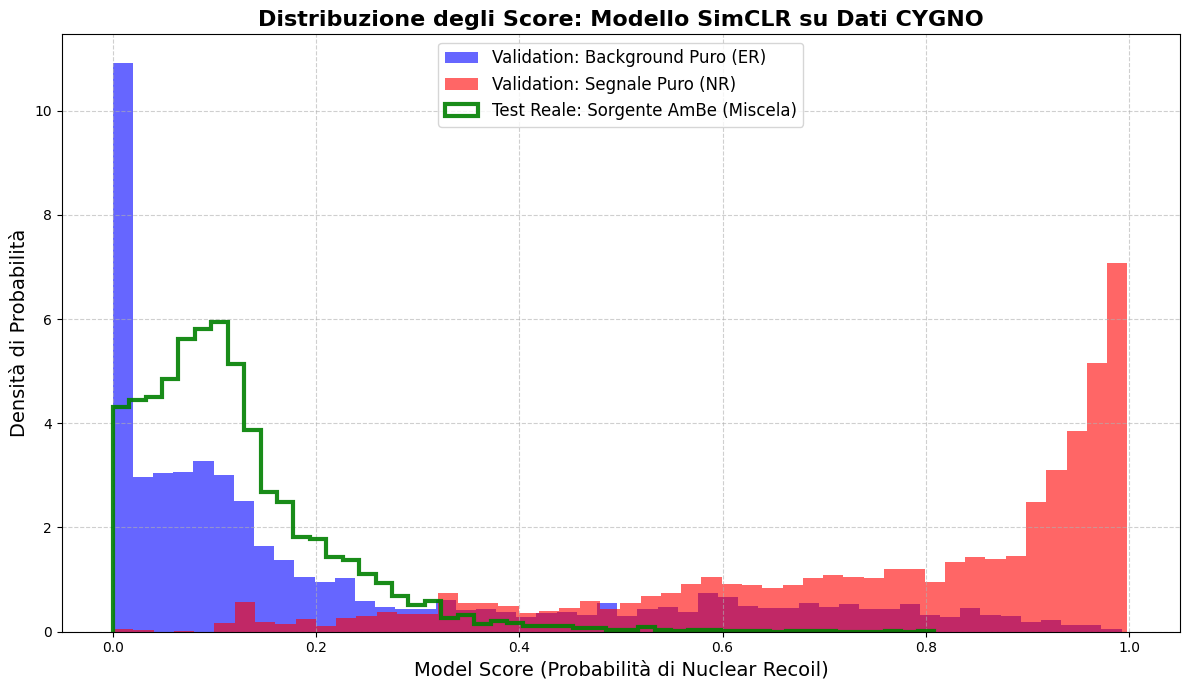


Statistiche Dataset AmBe:
- Tracce totali analizzate: 14724
- Tracce classificate come probabili Nuclear Recoils (Score > 0.8): 4
- Frazione stimata di segnale (Alpha): 0.03%


In [ ]:
# =====================================================================
# 6. INFERENCE & EVALUATION OF DISTRIBUTIONS (PHASE 3)
# =====================================================================

print("=== Avvio Fase 3: Inferenza e Valutazione delle Distribuzioni ===")

# 1. Calcoliamo le predizioni (score da 0 a 1) per il Validation Set e per l'AmBe
print("Calcolo delle predizioni in corso...")
# Se hai appena trainato il modello, puoi usare direttamente linear_eval_model
# Altrimenti scommenta la riga sotto per ricaricarlo dal disco:
linear_eval_model = keras.models.load_model("saved_models/CYGNO_Linear_Classifier_Final_ONLYREAL.keras")    

X_ambe_test = ambe_images_real


scores_val = linear_eval_model.predict(X_val, batch_size=128)
scores_ambe = linear_eval_model.predict(X_ambe_test, batch_size=128)

# 2. Separiamo il validation set usando le label reali per vedere come si comporta il modello
# y_val == 0 sono gli Electronic Recoils (Background)
# y_val == 1 sono i Nuclear Recoils (Signal)
scores_val_bg = scores_val[y_val == 0]
scores_val_sig = scores_val[y_val == 1]

# 3. Creazione del Plot a Istogramma con Densità di Probabilità
plt.figure(figsize=(12, 7))

# density=True fa in modo che l'area totale dell'istogramma sia 1 (Densità di probabilità)
# alpha=0.5 rende i colori trasparenti per vedere le sovrapposizioni

# Plot Background (ER) - Ci aspettiamo che sia tutto schiacciato verso lo 0
plt.hist(scores_val_bg, bins=50, density=True, alpha=0.6, color='blue', 
         label='Validation: Background Puro (ER)')

# Plot Segnale (NR) - Ci aspettiamo che sia tutto schiacciato verso l'1
plt.hist(scores_val_sig, bins=50, density=True, alpha=0.6, color='red', 
         label='Validation: Segnale Puro (NR)')

# Plot AmBe (Miscela Reale) - Usiamo histtype='step' per fare solo il contorno e non pasticciare i colori
plt.hist(scores_ambe, bins=50, density=True, alpha=0.9, color='green', 
         histtype='step', linewidth=3, label='Test Reale: Sorgente AmBe (Miscela)')

# Dettagli estetici del grafico
plt.xlabel('Model Score (Probabilità di Nuclear Recoil)', fontsize=14)
plt.ylabel('Densità di Probabilità', fontsize=14)
plt.title('Distribuzione degli Score: Modello SimCLR su Dati CYGNO', fontsize=16, fontweight='bold')
plt.xlim(-0.05, 1.05) # Fissiamo l'asse X tra 0 e 1 (con un minimo di margine)
plt.legend(fontsize=12, loc='upper center')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 4. Statistiche veloci sull'AmBe
soglia_taglio = 0.8
nr_candidates = np.sum(scores_ambe > soglia_taglio)
print(f"\nStatistiche Dataset AmBe:")
print(f"- Tracce totali analizzate: {len(scores_ambe)}")
print(f"- Tracce classificate come probabili Nuclear Recoils (Score > {soglia_taglio}): {nr_candidates}")
print(f"- Frazione stimata di segnale (Alpha): {(nr_candidates / len(scores_ambe))*100:.2f}%")

ALTERNATIVE WAYS TO HELP THE MODEL CLASSIFY REAL DATA

METHOD 1: APPLYING NOISE TO SIMULATED NRs TOO SO THAT THE CLASSIFIER HAS "LABEL 1" EVENTS AS (SIMULATED EVENTS+NOISE = REAL DATA)

In [8]:
# =====================================================================
# SOLUZIONE 1.1: ASSEMBLAGGIO FASE 2 (Con Pedestal Mixing per il Classificatore)
# =====================================================================

print("\n=== Assemblaggio Dataset per Fase 2 (da memoria RAM) ===")

# 1. Assegnazione Label (0 = Background, 1 = Signal)
y_std_real = np.zeros(std_images_real.shape[0], dtype=np.int32)
y_sim_er   = np.zeros(X_sim_er.shape[0], dtype=np.int32)
y_sim_nr   = np.ones(X_sim_nr.shape[0], dtype=np.int32)

# Uniamo SOLO Background Puro e Segnale Puro (Escludiamo l'AmBe mischiato)
X_labeled = np.concatenate([std_images_real, X_sim_er, X_sim_nr], axis=0)
y_labeled = np.concatenate([y_std_real, y_sim_er, y_sim_nr], axis=0)

# 2. Creazione dei Flag per il Pedestal Mixing (0 = Dati Reali, 1 = Simulazioni)
# Questo dirà alla pipeline a quali immagini deve essere iniettato il rumore!
flags_std_real = np.zeros(std_images_real.shape[0], dtype=np.float32)
flags_sim_er   = np.ones(X_sim_er.shape[0], dtype=np.float32)
flags_sim_nr   = np.ones(X_sim_nr.shape[0], dtype=np.float32)
flags_labeled  = np.concatenate([flags_std_real, flags_sim_er, flags_sim_nr], axis=0)

# 3. Train/Val Split (Lo stratify garantisce che le proporzioni rimangano costanti)
# NOTA: Ora passiamo anche i "flags_labeled" per splittarli in modo parallelo
X_train, X_val, y_train, y_val, flags_train, flags_val = train_test_split(
    X_labeled, 
    y_labeled, 
    flags_labeled,
    test_size=0.20, 
    random_state=42, 
    stratify=y_labeled 
)

print(f"Training set:   {X_train.shape[0]} images")
print(f"Validation set: {X_val.shape[0]} images")

# 4. Calcolo Pesi per Bilanciamento Classi (Cruciale per compensare il troppo STD)
total_samples = len(y_train)
class_0_count = np.sum(y_train == 0)
class_1_count = np.sum(y_train == 1)

class_weights = {
    0: (1 / class_0_count) * (total_samples / 2.0), 
    1: (1 / class_1_count) * (total_samples / 2.0)
}
print(f"Class Weights applicati -> Background: {class_weights[0]:.2f}, Signal: {class_weights[1]:.2f}")

# =====================================================================
# PIPELINE DINAMICHE TF.DATA PER IL CLASSIFICATORE
# =====================================================================
BATCH_SIZE = 128

def prepare_classifier_image(img, label, is_simulated_flag):
    """Applica augmentation fisica e inietta rumore dinamico sulle simulazioni."""
    img = augment_tf(img)
    
    # Definiamo il mixing internamente per evitare NameError di scope
    def apply_mixing_internal(view):
        return tf.clip_by_value(view + get_random_background(), 0.0, 1.0)
        
    img = tf.cond(is_simulated_flag > 0, lambda: apply_mixing_internal(img), lambda: img)
    return img, label

def prepare_val_image(img, label, is_simulated_flag):
    """NO augmentation in validation, ma il mixing serve per simulare i test veri!"""
    def apply_mixing(view):
        return tf.clip_by_value(view + get_random_background(), 0.0, 1.0)
        
    img = tf.cond(is_simulated_flag > 0, lambda: apply_mixing(img), lambda: img)
    return img, label

# Creazione dei Dataset
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train, flags_train))
train_ds = train_ds.shuffle(buffer_size=1024)
train_ds = train_ds.map(prepare_classifier_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val, flags_val))
val_ds = val_ds.map(prepare_val_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)




=== Assemblaggio Dataset per Fase 2 (da memoria RAM) ===
Training set:   38332 images
Validation set: 9584 images
Class Weights applicati -> Background: 0.76, Signal: 1.45


In [ ]:
# =====================================================================
# CREAZIONE E ADDESTRAMENTO MODELLO LINEARE (SU GPU)
# =====================================================================
print("\nLoading pre-trained encoder...")
final_model_path = "saved_models/CYGNO_Encoder_SimCLR_Final.keras"

with tf.device('/GPU:0'):
    encoder = keras.models.load_model(final_model_path)
    encoder.trainable = False  # CRITICAL: Freeze the base network

    inputs = keras.Input(shape=(128, 128, 1))
    
    # ESTRAZIONE DAL POOLING LAYER (Rappresentazione intermedia 128-dim, non 64-dim!)
    pool_layer = encoder.get_layer("global_average_pooling2d")
    feature_extractor = keras.Model(inputs=encoder.input, outputs=pool_layer.output)
    
    features = feature_extractor(inputs, training=False) 
    outputs = layers.Dense(1, activation="sigmoid", name="linear_classifier")(features)

    linear_eval_model = keras.Model(inputs, outputs, name="SimCLR_Linear_Eval_SOLUTION_1")

    linear_eval_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )

# -----------------------------------------------------------------
# CONFIGURAZIONE EARLY STOPPING PER IL CLASSIFICATORE
# -----------------------------------------------------------------
# Monitoriamo la loss di validazione. min_delta esclude oscillazioni infinitesimali.
early_stopping_classifier = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,                 # Un layer lineare converge in fretta, 7 epoche bastano
    min_delta=0.0005,           # Soglia minima di miglioramento significativo
    restore_best_weights=True,  # Ripristina lo stato dell'epoca migliore assoluta
    mode='min',
    verbose=1
)
# -----------------------------------------------------------------

print("\nTraining Linear Classifier on frozen representations with dynamic Pedestal Mixing...")
history = linear_eval_model.fit(
    train_ds,                  # Usiamo il Dataset preparato!
    epochs=50,                 # 50 epoche massime (ma l'early stopping si fermerà prima)
    validation_data=val_ds,
    class_weight=class_weights, # Passiamo i pesi bilanciati
    callbacks=[early_stopping_classifier] # <-- Integrazione del Callback
)

print("\n=== Linear Evaluation Complete ===")

final_classifier_path = "saved_models/CYGNO_Linear_Classifier_Final_SOLUTION_1.keras"
linear_eval_model.save(final_classifier_path)
print(f"Classification model successfully saved to: {final_classifier_path}")

=== Avvio Fase 3: Inferenza e Valutazione delle Distribuzioni ===
Calcolo delle predizioni in corso...
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 199ms/step
116/116 ━━━━━━━━━━━━━━━━━━━━ 23s 195ms/step


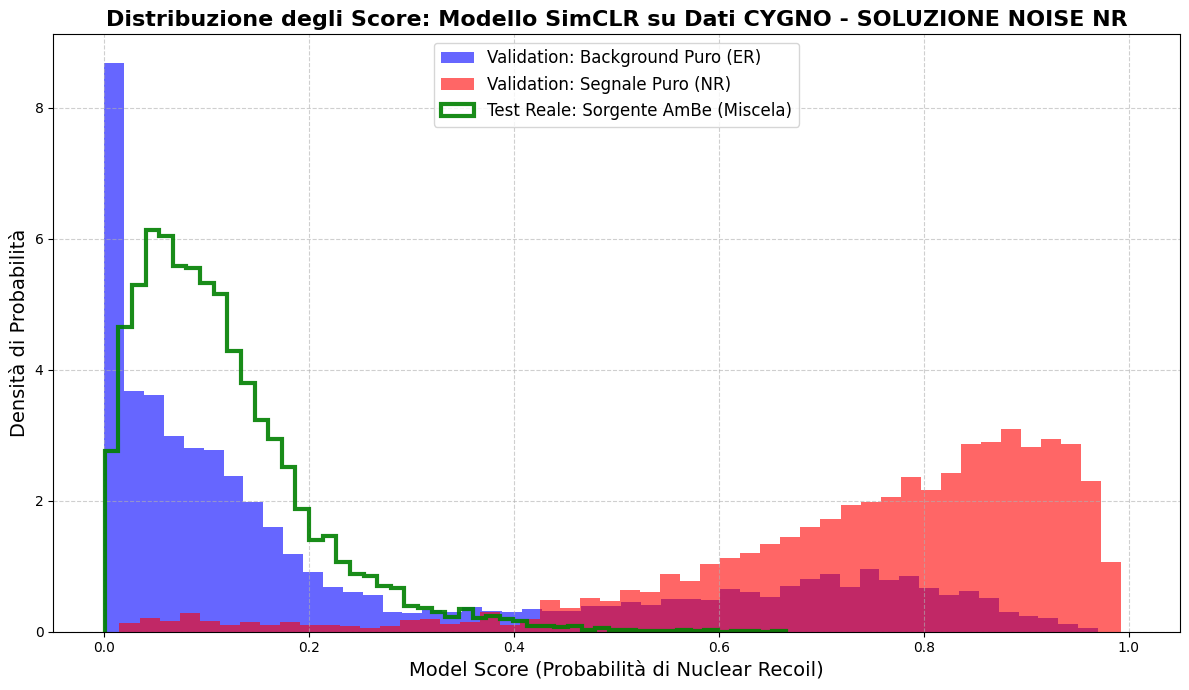


Statistiche Dataset AmBe:
- Tracce totali analizzate: 14724
- Tracce classificate come probabili Nuclear Recoils (Score > 0.8): 0
- Frazione stimata di segnale (Alpha): 0.00%


In [9]:
# =====================================================================
# 6. INFERENCE & EVALUATION OF DISTRIBUTIONS (PHASE 3) - CORRETTO
# =====================================================================

print("=== Avvio Fase 3: Inferenza e Valutazione delle Distribuzioni ===")

linear_eval_model = keras.models.load_model("saved_models/CYGNO_Linear_Classifier_Final_SOLUTION_1.keras")

# 1. Creiamo una Pipeline di Inferenza per X_val (Per iniettare il rumore senza Shuffle!)
def prepare_infer_image(img, is_simulated_flag):
    def apply_mixing(view):
        return tf.clip_by_value(view + get_random_background(), 0.0, 1.0)
    # Applica il rumore solo alle simulazioni (flag > 0)
    img = tf.cond(is_simulated_flag > 0, lambda: apply_mixing(img), lambda: img)
    return img

val_infer_ds = tf.data.Dataset.from_tensor_slices((X_val, flags_val))
val_infer_ds = val_infer_ds.map(prepare_infer_image, num_parallel_calls=tf.data.AUTOTUNE)
val_infer_ds = val_infer_ds.batch(128).prefetch(tf.data.AUTOTUNE)

print("Calcolo delle predizioni in corso...")
# Usiamo la pipeline appena creata invece dell'array grezzo X_val
scores_val = linear_eval_model.predict(val_infer_ds)

# X_ambe_test è già reale (ha già il suo rumore), quindi per lui va benissimo l'array grezzo!
X_ambe_test = ambe_images_real
scores_ambe = linear_eval_model.predict(X_ambe_test, batch_size=128)

# -- IL RESTO DEL TUO CODICE PER IL PLOT RIMANE IDENTICO --
scores_val = np.squeeze(scores_val) # Assicuriamoci che sia 1D
scores_val_bg = scores_val[y_val == 0]
scores_val_sig = scores_val[y_val == 1]

# 3. Creazione del Plot a Istogramma con Densità di Probabilità
plt.figure(figsize=(12, 7))

# density=True fa in modo che l'area totale dell'istogramma sia 1 (Densità di probabilità)
# alpha=0.5 rende i colori trasparenti per vedere le sovrapposizioni

# Plot Background (ER) - Ci aspettiamo che sia tutto schiacciato verso lo 0
plt.hist(scores_val_bg, bins=50, density=True, alpha=0.6, color='blue', 
         label='Validation: Background Puro (ER)')

# Plot Segnale (NR) - Ci aspettiamo che sia tutto schiacciato verso l'1
plt.hist(scores_val_sig, bins=50, density=True, alpha=0.6, color='red', 
         label='Validation: Segnale Puro (NR)')

# Plot AmBe (Miscela Reale) - Usiamo histtype='step' per fare solo il contorno e non pasticciare i colori
plt.hist(scores_ambe, bins=50, density=True, alpha=0.9, color='green', 
         histtype='step', linewidth=3, label='Test Reale: Sorgente AmBe (Miscela)')

# Dettagli estetici del grafico
plt.xlabel('Model Score (Probabilità di Nuclear Recoil)', fontsize=14)
plt.ylabel('Densità di Probabilità', fontsize=14)
plt.title('Distribuzione degli Score: Modello SimCLR su Dati CYGNO - SOLUZIONE NOISE NR', fontsize=16, fontweight='bold')
plt.xlim(-0.05, 1.05) # Fissiamo l'asse X tra 0 e 1 (con un minimo di margine)
plt.legend(fontsize=12, loc='upper center')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 4. Statistiche veloci sull'AmBe
soglia_taglio = 0.8
nr_candidates = np.sum(scores_ambe > soglia_taglio)
print(f"\nStatistiche Dataset AmBe:")
print(f"- Tracce totali analizzate: {len(scores_ambe)}")
print(f"- Tracce classificate come probabili Nuclear Recoils (Score > {soglia_taglio}): {nr_candidates}")
print(f"- Frazione stimata di segnale (Alpha): {(nr_candidates / len(scores_ambe))*100:.2f}%")

mini modifica: abbassiamo il learning rate e rendiamo dinamico l'encoder, in modo da estrarre le feature dei NR

In [14]:
# =====================================================================
# CREAZIONE E ADDESTRAMENTO MODELLO LINEARE (SU GPU)
# =====================================================================
print("\nLoading pre-trained encoder...")
final_model_path = "saved_models/CYGNO_Encoder_SimCLR_Final.keras"

with tf.device('/GPU:0'):
    encoder = keras.models.load_model(final_model_path)
    encoder.trainable = True  # CRITICAL: Freeze the base network

    inputs = keras.Input(shape=(128, 128, 1))
    
    # ESTRAZIONE DAL POOLING LAYER (Rappresentazione intermedia 128-dim, non 64-dim!)
    pool_layer = encoder.get_layer("global_average_pooling2d")
    feature_extractor = keras.Model(inputs=encoder.input, outputs=pool_layer.output)
    
    features = feature_extractor(inputs, training=False) 
    outputs = layers.Dense(1, activation="sigmoid", name="linear_classifier")(features)

    linear_eval_model = keras.Model(inputs, outputs, name="SimCLR_Linear_Eval_SOLUTION_1_DYNAMIC")

    linear_eval_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )

# -----------------------------------------------------------------
# CONFIGURAZIONE EARLY STOPPING PER IL CLASSIFICATORE
# -----------------------------------------------------------------
# Monitoriamo la loss di validazione. min_delta esclude oscillazioni infinitesimali.
early_stopping_classifier = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,                 # Un layer lineare converge in fretta, 7 epoche bastano
    min_delta=0.0005,           # Soglia minima di miglioramento significativo
    restore_best_weights=True,  # Ripristina lo stato dell'epoca migliore assoluta
    mode='min',
    verbose=1
)
# -----------------------------------------------------------------

print("\nTraining Linear Classifier on frozen representations with dynamic Pedestal Mixing...")
history = linear_eval_model.fit(
    train_ds,                  # Usiamo il Dataset preparato!
    epochs=65,                 # 50 epoche massime (ma l'early stopping si fermerà prima)
    validation_data=val_ds,
    class_weight=class_weights, # Passiamo i pesi bilanciati
    callbacks=[early_stopping_classifier] # <-- Integrazione del Callback
)

print("\n=== Linear Evaluation Complete ===")

final_classifier_path = "saved_models/CYGNO_Linear_Classifier_Final_SOLUTION_1_DYNAMIC.keras"
linear_eval_model.save(final_classifier_path)
print(f"Classification model successfully saved to: {final_classifier_path}")


Loading pre-trained encoder...

Training Linear Classifier on frozen representations with dynamic Pedestal Mixing...
Epoch 1/65
300/300 ━━━━━━━━━━━━━━━━━━━━ 451s 1s/step - accuracy: 0.6300 - auc: 0.7286 - loss: 0.6444 - val_accuracy: 0.6460 - val_auc: 0.7839 - val_loss: 0.6335
Epoch 2/65
300/300 ━━━━━━━━━━━━━━━━━━━━ 448s 1s/step - accuracy: 0.6636 - auc: 0.8015 - loss: 0.5864 - val_accuracy: 0.6669 - val_auc: 0.8214 - val_loss: 0.5908
Epoch 3/65
300/300 ━━━━━━━━━━━━━━━━━━━━ 447s 1s/step - accuracy: 0.6764 - auc: 0.8219 - loss: 0.5551 - val_accuracy: 0.6799 - val_auc: 0.8360 - val_loss: 0.5685
Epoch 4/65
300/300 ━━━━━━━━━━━━━━━━━━━━ 449s 1s/step - accuracy: 0.6824 - auc: 0.8359 - loss: 0.5336 - val_accuracy: 0.6918 - val_auc: 0.8533 - val_loss: 0.5543
Epoch 5/65
300/300 ━━━━━━━━━━━━━━━━━━━━ 448s 1s/step - accuracy: 0.6924 - auc: 0.8434 - loss: 0.5201 - val_accuracy: 0.7030 - val_auc: 0.8530 - val_loss: 0.5364
Epoch 6/65
300/300 ━━━━━━━━━━━━━━━━━━━━ 447s 1s/step - accuracy: 0.7029 - auc

=== Avvio Fase 3: Inferenza e Valutazione delle Distribuzioni ===
Calcolo delle predizioni in corso...
75/75 ━━━━━━━━━━━━━━━━━━━━ 15s 196ms/step
116/116 ━━━━━━━━━━━━━━━━━━━━ 23s 194ms/step


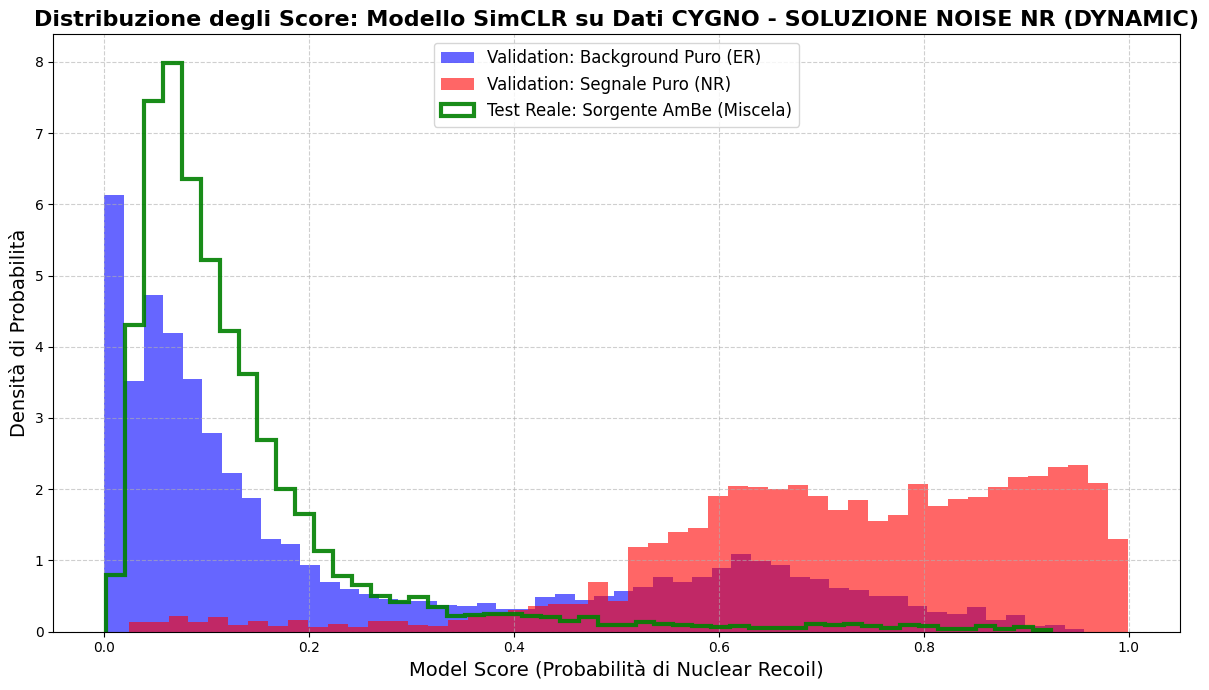


Statistiche Dataset AmBe:
- Tracce totali analizzate: 14724
- Tracce classificate come probabili Nuclear Recoils (Score > 0.8): 94
- Frazione stimata di segnale (Alpha): 0.64%


In [15]:
# =====================================================================
# 6. INFERENCE & EVALUATION OF DISTRIBUTIONS (PHASE 3) - CORRETTO
# =====================================================================

print("=== Avvio Fase 3: Inferenza e Valutazione delle Distribuzioni ===")

linear_eval_model = keras.models.load_model("saved_models/CYGNO_Linear_Classifier_Final_SOLUTION_1_DYNAMIC.keras")

# 1. Creiamo una Pipeline di Inferenza per X_val (Per iniettare il rumore senza Shuffle!)
def prepare_infer_image(img, is_simulated_flag):
    def apply_mixing(view):
        return tf.clip_by_value(view + get_random_background(), 0.0, 1.0)
    # Applica il rumore solo alle simulazioni (flag > 0)
    img = tf.cond(is_simulated_flag > 0, lambda: apply_mixing(img), lambda: img)
    return img

val_infer_ds = tf.data.Dataset.from_tensor_slices((X_val, flags_val))
val_infer_ds = val_infer_ds.map(prepare_infer_image, num_parallel_calls=tf.data.AUTOTUNE)
val_infer_ds = val_infer_ds.batch(128).prefetch(tf.data.AUTOTUNE)

print("Calcolo delle predizioni in corso...")
# Usiamo la pipeline appena creata invece dell'array grezzo X_val
scores_val = linear_eval_model.predict(val_infer_ds)

# X_ambe_test è già reale (ha già il suo rumore), quindi per lui va benissimo l'array grezzo!
X_ambe_test = ambe_images_real
scores_ambe = linear_eval_model.predict(X_ambe_test, batch_size=128)

# -- IL RESTO DEL TUO CODICE PER IL PLOT RIMANE IDENTICO --
scores_val = np.squeeze(scores_val) # Assicuriamoci che sia 1D
scores_val_bg = scores_val[y_val == 0]
scores_val_sig = scores_val[y_val == 1]

# 3. Creazione del Plot a Istogramma con Densità di Probabilità
plt.figure(figsize=(12, 7))

# density=True fa in modo che l'area totale dell'istogramma sia 1 (Densità di probabilità)
# alpha=0.5 rende i colori trasparenti per vedere le sovrapposizioni

# Plot Background (ER) - Ci aspettiamo che sia tutto schiacciato verso lo 0
plt.hist(scores_val_bg, bins=50, density=True, alpha=0.6, color='blue', 
         label='Validation: Background Puro (ER)')

# Plot Segnale (NR) - Ci aspettiamo che sia tutto schiacciato verso l'1
plt.hist(scores_val_sig, bins=50, density=True, alpha=0.6, color='red', 
         label='Validation: Segnale Puro (NR)')

# Plot AmBe (Miscela Reale) - Usiamo histtype='step' per fare solo il contorno e non pasticciare i colori
plt.hist(scores_ambe, bins=50, density=True, alpha=0.9, color='green', 
         histtype='step', linewidth=3, label='Test Reale: Sorgente AmBe (Miscela)')

# Dettagli estetici del grafico
plt.xlabel('Model Score (Probabilità di Nuclear Recoil)', fontsize=14)
plt.ylabel('Densità di Probabilità', fontsize=14)
plt.title('Distribuzione degli Score: Modello SimCLR su Dati CYGNO - SOLUZIONE NOISE NR (DYNAMIC)', fontsize=16, fontweight='bold')
plt.xlim(-0.05, 1.05) # Fissiamo l'asse X tra 0 e 1 (con un minimo di margine)
plt.legend(fontsize=12, loc='upper center')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 4. Statistiche veloci sull'AmBe
soglia_taglio = 0.8
nr_candidates = np.sum(scores_ambe > soglia_taglio)
print(f"\nStatistiche Dataset AmBe:")
print(f"- Tracce totali analizzate: {len(scores_ambe)}")
print(f"- Tracce classificate come probabili Nuclear Recoils (Score > {soglia_taglio}): {nr_candidates}")
print(f"- Frazione stimata di segnale (Alpha): {(nr_candidates / len(scores_ambe))*100:.2f}%")

METHOD 2: APPLICATION OF CWOLA TO TRAIN THE CLASSIFIER

In [12]:
# =====================================================================
# SOLUTION 2: ASSEMBLAGGIO E TRAINING FASE 2 (Approccio CWoLa Puro)
# =====================================================================

print("\n=== Assemblaggio Dataset per Fase 2 (Approccio CWoLa) ===")

# In CWoLa, si ignorano totalmente le simulazioni. Si usano solo dati REALI.
# Label 0: Background Puro (Dati STD)
# Label 1: Miscela Contenente Segnale (Dati AmBe)

y_std_real = np.zeros(std_images_real.shape[0], dtype=np.int32)
y_ambe_real = np.ones(ambe_images_real.shape[0], dtype=np.int32)

X_cwola = np.concatenate([std_images_real, ambe_images_real], axis=0)
y_cwola = np.concatenate([y_std_real, y_ambe_real], axis=0)

# Train/Val Split (Nessun flag qui, sono tutti dati reali!)
X_train, X_val, y_train, y_val = train_test_split(
    X_cwola, 
    y_cwola, 
    test_size=0.20, 
    random_state=42, 
    stratify=y_cwola 
)

# Bilanciamento delle classi (Utile se in futuro i dataset avranno size diverse)
total_samples = len(y_train)
class_0_count = np.sum(y_train == 0)
class_1_count = np.sum(y_train == 1)

class_weights = {
    0: (1 / class_0_count) * (total_samples / 2.0), 
    1: (1 / class_1_count) * (total_samples / 2.0)
}
print(f"Dataset CWoLa Assemblato. Dati STD (0): {class_0_count} | Dati AmBe (1): {class_1_count}")
print(f"Class Weights CWoLa: {class_weights}")

# =====================================================================
# PIPELINE TF.DATA SPECIFICA PER CWOLA (NO MIXING, SOLO AUGMENTATION)
# =====================================================================
BATCH_SIZE = 128

# Applichiamo SOLO le rotazioni/flip spaziali al set di addestramento
def prepare_cwola_train(img, label):
    return augment_tf(img), label

# Creazione Dataset Training
train_ds_cwola = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds_cwola = train_ds_cwola.shuffle(buffer_size=1024)
train_ds_cwola = train_ds_cwola.map(prepare_cwola_train, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_cwola = train_ds_cwola.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Creazione Dataset Validation (Nessuna trasformazione, dati puri)
val_ds_cwola = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds_cwola = val_ds_cwola.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# =====================================================================
# CARICAMENTO ENCODER E CREAZIONE CLASSIFICATORE CWOLA
# =====================================================================
print("\nLoading pre-trained encoder...")
final_model_path = "saved_models/CYGNO_Encoder_SimCLR_Final.keras"

with tf.device('/GPU:0'):
    encoder = keras.models.load_model(final_model_path)
    encoder.trainable = False  # CRITICAL: Freeze the base network

    inputs = keras.Input(shape=(128, 128, 1))
    
    # ESTRAZIONE DAL POOLING LAYER (Rappresentazione intermedia 128-dim)
    pool_layer = encoder.get_layer("global_average_pooling2d")
    feature_extractor = keras.Model(inputs=encoder.input, outputs=pool_layer.output)
    
    features = feature_extractor(inputs, training=False) 
    outputs = layers.Dense(1, activation="sigmoid", name="linear_classifier")(features)

    linear_eval_model = keras.Model(inputs, outputs, name="SimCLR_Linear_Eval_SOLUTION_CWOLA")

    linear_eval_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )

# -----------------------------------------------------------------
# CONFIGURAZIONE EARLY STOPPING (Stessi criteri solidi della Soluzione 1)
# -----------------------------------------------------------------
early_stopping_cwola = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,                 
    min_delta=0.0005,           
    restore_best_weights=True,  
    mode='min',
    verbose=1
)
# -----------------------------------------------------------------

print("\nTraining Linear Classifier using CWoLa approach (Pure Real Data)...")
history = linear_eval_model.fit(
    train_ds_cwola,            # <-- Utilizziamo il dataset CWoLa dedicato!
    epochs=50,                 
    validation_data=val_ds_cwola,
    class_weight=class_weights,
    callbacks=[early_stopping_cwola] # <-- Early Stopping attivato
)

print("\n=== CWoLa Linear Evaluation Complete ===")

final_classifier_path = "saved_models/CYGNO_Linear_Classifier_Final_SOLUTION_CWOLA.keras"
linear_eval_model.save(final_classifier_path)
print(f"Classification model successfully saved to: {final_classifier_path}")


=== Assemblaggio Dataset per Fase 2 (Approccio CWoLa) ===
Dataset CWoLa Assemblato. Dati STD (0): 11800 | Dati AmBe (1): 11779
Class Weights CWoLa: {0: 0.9991101694915255, 1: 1.000891416928432}

Loading pre-trained encoder...

Training Linear Classifier using CWoLa approach (Pure Real Data)...
Epoch 1/50


C:\Users\Mattia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


185/185 ━━━━━━━━━━━━━━━━━━━━ 49s 245ms/step - accuracy: 0.5327 - auc: 0.5435 - loss: 0.6912 - val_accuracy: 0.5442 - val_auc: 0.5947 - val_loss: 0.6875
Epoch 2/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 45s 245ms/step - accuracy: 0.5688 - auc: 0.5939 - loss: 0.6851 - val_accuracy: 0.5730 - val_auc: 0.6077 - val_loss: 0.6829
Epoch 3/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 45s 246ms/step - accuracy: 0.5753 - auc: 0.6031 - loss: 0.6815 - val_accuracy: 0.5744 - val_auc: 0.6108 - val_loss: 0.6800
Epoch 4/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 45s 242ms/step - accuracy: 0.5789 - auc: 0.6074 - loss: 0.6791 - val_accuracy: 0.5788 - val_auc: 0.6127 - val_loss: 0.6777
Epoch 5/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 45s 243ms/step - accuracy: 0.5807 - auc: 0.6112 - loss: 0.6773 - val_accuracy: 0.5812 - val_auc: 0.6132 - val_loss: 0.6762
Epoch 6/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 45s 242ms/step - accuracy: 0.5812 - auc: 0.6105 - loss: 0.6761 - val_accuracy: 0.5813 - val_auc: 0.6144 - val_loss: 0.6748
Epoch 7/50
185/185 ━━━━━━━━━━━━━━

=== Avvio Fase 3: Inferenza e Valutazione delle Distribuzioni ===
Calcolo delle predizioni in corso...
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 199ms/step
116/116 ━━━━━━━━━━━━━━━━━━━━ 23s 194ms/step


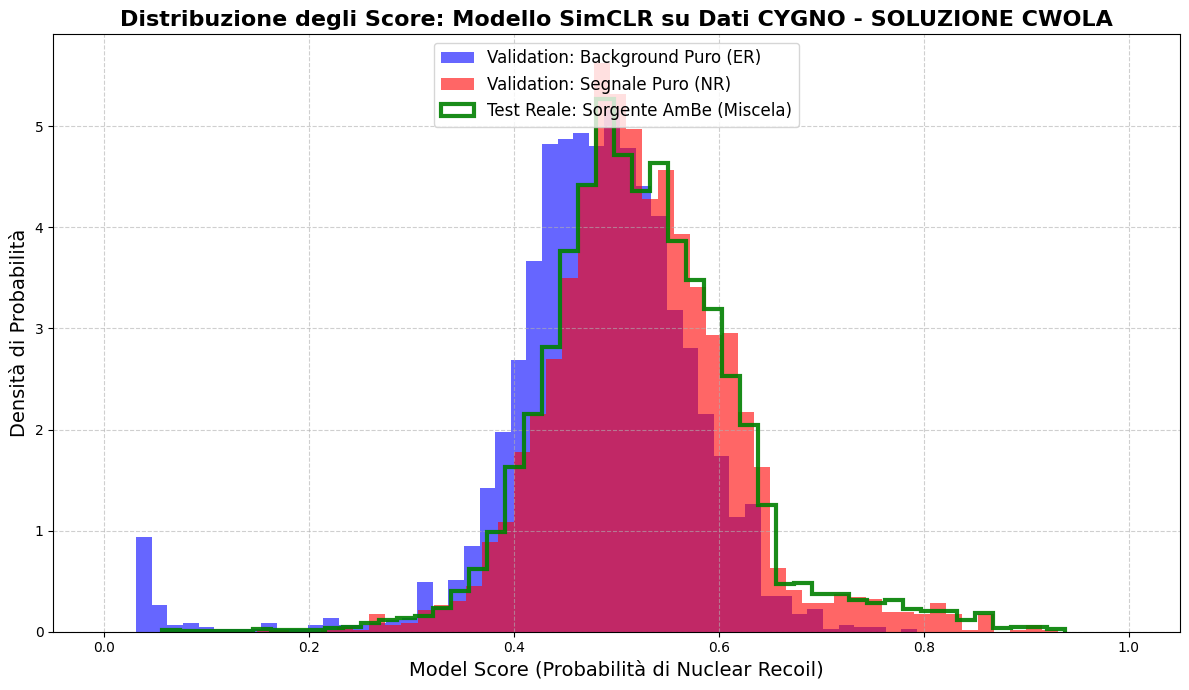


Statistiche Dataset AmBe:
- Tracce totali analizzate: 14724
- Tracce classificate come probabili Nuclear Recoils (Score > 0.8): 214
- Frazione stimata di segnale (Alpha): 1.45%


In [13]:
# =====================================================================
# 6. INFERENCE & EVALUATION OF DISTRIBUTIONS (PHASE 3)
# =====================================================================

print("=== Avvio Fase 3: Inferenza e Valutazione delle Distribuzioni ===")

# 1. Calcoliamo le predizioni (score da 0 a 1) per il Validation Set e per l'AmBe
print("Calcolo delle predizioni in corso...")
# Se hai appena trainato il modello, puoi usare direttamente linear_eval_model
# Altrimenti scommenta la riga sotto per ricaricarlo dal disco:
linear_eval_model = keras.models.load_model("saved_models/CYGNO_Linear_Classifier_Final_SOLUTION_CWOLA.keras")

X_ambe_test = ambe_images_real


scores_val = linear_eval_model.predict(X_val, batch_size=128)
scores_ambe = linear_eval_model.predict(X_ambe_test, batch_size=128)

# 2. Separiamo il validation set usando le label reali per vedere come si comporta il modello
# y_val == 0 sono gli Electronic Recoils (Background)
# y_val == 1 sono i Nuclear Recoils (Signal)
scores_val_bg = scores_val[y_val == 0]
scores_val_sig = scores_val[y_val == 1]

# 3. Creazione del Plot a Istogramma con Densità di Probabilità
plt.figure(figsize=(12, 7))

# density=True fa in modo che l'area totale dell'istogramma sia 1 (Densità di probabilità)
# alpha=0.5 rende i colori trasparenti per vedere le sovrapposizioni

# Plot Background (ER) - Ci aspettiamo che sia tutto schiacciato verso lo 0
plt.hist(scores_val_bg, bins=50, density=True, alpha=0.6, color='blue', 
         label='Validation: Background Puro (ER)')

# Plot Segnale (NR) - Ci aspettiamo che sia tutto schiacciato verso l'1
plt.hist(scores_val_sig, bins=50, density=True, alpha=0.6, color='red', 
         label='Validation: Segnale Puro (NR)')

# Plot AmBe (Miscela Reale) - Usiamo histtype='step' per fare solo il contorno e non pasticciare i colori
plt.hist(scores_ambe, bins=50, density=True, alpha=0.9, color='green', 
         histtype='step', linewidth=3, label='Test Reale: Sorgente AmBe (Miscela)')

# Dettagli estetici del grafico
plt.xlabel('Model Score (Probabilità di Nuclear Recoil)', fontsize=14)
plt.ylabel('Densità di Probabilità', fontsize=14)
plt.title('Distribuzione degli Score: Modello SimCLR su Dati CYGNO - SOLUZIONE CWOLA', fontsize=16, fontweight='bold')
plt.xlim(-0.05, 1.05) # Fissiamo l'asse X tra 0 e 1 (con un minimo di margine)
plt.legend(fontsize=12, loc='upper center')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 4. Statistiche veloci sull'AmBe
soglia_taglio = 0.8
nr_candidates = np.sum(scores_ambe > soglia_taglio)
print(f"\nStatistiche Dataset AmBe:")
print(f"- Tracce totali analizzate: {len(scores_ambe)}")
print(f"- Tracce classificate come probabili Nuclear Recoils (Score > {soglia_taglio}): {nr_candidates}")
print(f"- Frazione stimata di segnale (Alpha): {(nr_candidates / len(scores_ambe))*100:.2f}%")